# 📘 Agentic 架构 6：Planner → Executor → Verifier（PEV）

本 notebook 探讨 **Planner → Executor → Verifier（PEV）** 架构，它在智能体系统中引入关键的稳健性与自我纠错能力。该架构借鉴严格的软件工程与质量保证流程：在完成验证之前，工作不应被视为「已完成」。

标准规划型智能体虽然能带来结构与可预期性，但隐含一个关键假设：工具每次都会完美运行并返回有效数据。在现实世界中，API 会失败、检索可能无结果、数据也可能格式错误。PEV 通过增加专职 **Verifier（验证器）** 智能体，在每次行动后进行质量把关，使系统能够发现失败并动态恢复。

为说明其价值，我们先搭建标准的 **Planner–Executor（规划–执行）智能体**，展示在工具返回错误时它会如何失败；再搭建完整的 **PEV 智能体**，展示 Verifier 如何捕获错误、触发重规划循环，并最终引导系统走向成功结果。

### 定义
**Planner → Executor → Verifier（PEV）** 架构是一种三阶段工作流，将规划、执行与验证显式分离。它确保每一步的输出在继续之前都经过校验，从而形成稳健、可自我纠正的循环。

### 高层工作流

1. **Plan（规划）：**「Planner」智能体将高层目标分解为一系列可执行的具体步骤。
2. **Execute（执行）：**「Executor」智能体从计划中取出 *下一步*，并调用相应工具。
3. **Verify（验证）：**「Verifier」智能体检查 Executor 的输出，判断正确性、相关性及潜在错误，并给出判断：该步是成功还是失败？
4. **Route & Iterate（路由与迭代）：**根据 Verifier 的结论，路由器决定下一步：
   * 若该步 **成功** 且计划尚未完成，则回到 Executor 执行下一步。
   * 若该步 **失败**，则回到 Planner 制定 *新* 计划，通常附带失败上下文，使新计划更明智。
   * 若该步 **成功** 且计划已完成，则进入最终综合（合成）步骤。

### 适用场景 / 应用
* **安全关键应用（金融、医疗）：**当错误代价很高时，PEV 提供必要护栏，防止智能体在错误数据上行动。
* **工具不可靠的系统：**面对可能不稳定或返回不一致数据的外部 API 时，Verifier 可以优雅地捕获失败。
* **高精度任务（法律、科学）：**对事实准确度要求高的任务，Verifier 确保每条检索信息在进入下游推理前均有效。

### 优势与局限
* **优势：**
    * **稳健性与可靠性：**核心能力在于检测错误并恢复。
    * **模块化：**职责分离使系统更易调试与维护。
* **局限：**
    * **延迟与成本增加：**每一步后都增加验证，会多调用 LLM，是目前所介绍架构中最慢、最贵的一类。
    * **Verifier 设计难度：**有效的 Verifier 不易设计，需能区分轻微问题与致命失败。

## 阶段 0：基础与环境

我们将先安装库，并为 DeepSeek、LangSmith 及工具配置 API 密钥。

### 步骤 0.1：安装核心库

**本节操作：**
安装本系列项目常用的依赖套件。

In [1]:
# !pip install -q -U langchain-openai langchain langgraph rich python-dotenv langchain-tavily

### 步骤 0.2：导入库并配置密钥

**本节操作：**
导入所需模块，并从 `.env` 文件加载 API 密钥。

**需要您操作：** 在本目录创建 `.env` 并填入密钥：
```
DEEPSEEK_API_KEY="your_deepseek_api_key_here"
LANGCHAIN_API_KEY="your_langsmith_api_key_here"
TAVILY_API_KEY="your_tavily_api_key_here"
``````

In [1]:
import os
import re
from typing import List, Annotated, TypedDict, Optional
from dotenv import load_dotenv
import json

# LangChain components
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage, ToolMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown

# --- API Key and Tracing Setup ---
load_dotenv()
api_key = os.getenv("DEEPSEEK_API_KEY")

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - PEV (DeepSeek)"

for key in ["DEEPSEEK_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## 阶段 1：基线——Planner–Executor 智能体

要理解为何需要 Verifier，先要搭建一个没有它的智能体。该智能体会制定计划并机械执行，以展示工具调用出错时可能发生的失败。

### 步骤 1.1：构建 Planner–Executor 智能体

**本节操作：**
构建简单的 Planner–Executor 图（与前一 notebook 类似）。为模拟现实失败，我们创建一个特殊的「不稳定」工具：对某一特定查询会故意返回错误，而基线智能体无法处理这种情况。

In [8]:
console = Console()
llm = ChatOpenAI(
    model="deepseek-chat",
    api_key=api_key,
    base_url="https://api.deepseek.com/v1",
    temperature=0,
)

# Define a 'flaky' tool that will fail for a specific query
def flaky_web_search(query: str) -> str:
    """Performs a web search, but is designed to fail for a specific query."""
    console.print(f"--- TOOL: Searching for '{query}'... ---")
    if "employee count" in query.lower():
        console.print("--- TOOL: [bold red]Simulating API failure![/bold red] ---")
        return "Error: Could not retrieve data. The API endpoint is currently unavailable."
    else:
        result = TavilySearch(max_results=2).invoke(query)
        # 🔑 Ensure result is always a string
        if isinstance(result, (dict, list)):
            return json.dumps(result, indent=2)
        return str(result)

# Define the state for the basic P-E agent
class BasicPEState(TypedDict):
    user_request: str
    plan: Optional[List[str]]
    intermediate_steps: List[str]
    final_answer: Optional[str]

class Plan(BaseModel):
    steps: List[str] = Field(description="A list of tool calls to execute.")

def basic_planner_node(state: BasicPEState):
    console.print("--- (Basic) PLANNER: Creating plan... ---")
    planner_llm = llm.with_structured_output(Plan)

    prompt = f"""
    You are a planning agent. 
    Your job is to decompose the user's request into a list of clear tool queries.

    - Only return JSON that matches this schema: {{ "steps": [ "query1", "query2", ... ] }}
    - Do NOT return any prose or explanation.
    - Always use the 'flaky_web_search' tool for queries.

    User's request: "{state['user_request']}"
    """
    plan = planner_llm.invoke(prompt)
    return {"plan": plan.steps}

def basic_executor_node(state: BasicPEState):
    console.print("--- (Basic) EXECUTOR: Running next step... ---")
    next_step = state["plan"][0]
    result = flaky_web_search(next_step)
    return {"plan": state["plan"][1:], "intermediate_steps": state["intermediate_steps"] + [result]}

def basic_synthesizer_node(state: BasicPEState):
    console.print("--- (Basic) SYNTHESIZER: Generating final answer... ---")
    context = "\n".join(state["intermediate_steps"])
    prompt = f"Synthesize an answer for '{state['user_request']}' using this data:\n{context}"
    answer = llm.invoke(prompt).content
    return {"final_answer": answer}

# Build the graph
pe_graph_builder = StateGraph(BasicPEState)
pe_graph_builder.add_node("plan", basic_planner_node)
pe_graph_builder.add_node("execute", basic_executor_node)
pe_graph_builder.add_node("synthesize", basic_synthesizer_node)

pe_graph_builder.set_entry_point("plan")
pe_graph_builder.add_conditional_edges("plan", lambda s: "execute" if s["plan"] else "synthesize")
pe_graph_builder.add_conditional_edges("execute", lambda s: "execute" if s["plan"] else "synthesize")
pe_graph_builder.add_edge("synthesize", END)

basic_pe_app = pe_graph_builder.compile()
print("Basic Planner-Executor agent compiled successfully.")

Basic Planner-Executor agent compiled successfully.


### 步骤 1.2：在「不稳定」问题上测试基线智能体

**本节操作：**
让基线智能体执行一项任务，使其必须以会触发失败的查询调用 `flaky_web_search`，以展示其无法处理该错误。

In [9]:
flaky_query = "What was Apple's R&D spend in their last fiscal year, and what was their total employee count? Calculate the R&D spend per employee."

console.print(f"[bold yellow]Testing BASIC P-E agent on a flaky query:[/bold yellow]\n'{flaky_query}'\n")

initial_pe_input = {"user_request": flaky_query, "intermediate_steps": []}
final_pe_output = basic_pe_app.invoke(initial_pe_input)

console.print("\n--- [bold red]Final Output from Basic P-E Agent[/bold red] ---")
console.print(Markdown(final_pe_output['final_answer']))

Testing BASIC P-E agent on a flaky query:
'What was Apple's R&D spend in their last fiscal year, and what was their total employee count? Calculate the R&D 
spend per employee.'

--- (Basic) PLANNER: Creating plan... ---

BadRequestError: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}

**输出讨论：**
如预期那样失败。执行轨迹显示智能体制定了计划（很可能是 `["Apple R&D spend last fiscal year", "Apple total employee count"]`）。第一步成功执行；但第二步中，`flaky_web_search` 返回了错误信息字符串。

关键失败在最后一步。**Synthesizer（综合器）** 无法知道第二步失败，把错误信息当作有效数据接收，因此最终答案没有意义，往往会说「因某条输入是错误信息而无法计算」等。它盲目执行完计划，产出无用结果。这说明验证步骤至关重要。

## 阶段 2：进阶方案——Planner–Executor–Verifier 智能体

接下来搭建完整 PEV 智能体：增加专职 **Verifier** 节点，并实现更复杂的路由逻辑，使智能体能够从工具失败中恢复。

### 步骤 2.1：定义 Verifier 与 PEV 图

**本节操作：**
1. 定义 Verifier 结构化输出用的 Pydantic 模型 `VerificationResult`。
2. 创建 `verifier_node`，分析 Executor 的输出。
3. 创建新的、更复杂的 `router`，能根据 Verifier 的反馈触发重规划循环。

C:\Users\red\AppData\Local\Temp\ipykernel_35016\4049076629.py:17: PydanticDeprecatedSince20: `max_items` is deprecated and will be removed, use `max_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  steps: List[str] = Field(


Planner-Executor-Verifier (PEV) agent compiled successfully.


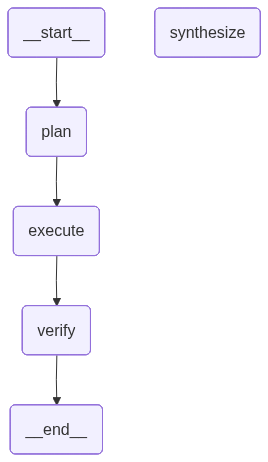

In [11]:
class VerificationResult(BaseModel):
    """Schema for the Verifier's output."""
    is_successful: bool = Field(description="True if the tool execution was successful and the data is valid.")
    reasoning: str = Field(description="Reasoning for the verification decision.")

class PEVState(TypedDict):
    user_request: str
    plan: Optional[List[str]]
    last_tool_result: Optional[str]
    intermediate_steps: List[str]
    final_answer: Optional[str]
    retries: int  # count how many times we’ve replanned

from langchain_core.exceptions import OutputParserException

class Plan(BaseModel):
    steps: List[str] = Field(
        description="List of queries (max 5).",
        max_items=5
    )

def pev_planner_node(state: PEVState):
    retries = state.get("retries", 0)
    if retries > 3:  # stop after 3 replans
        console.print("--- (PEV) PLANNER: Retry limit reached. Stopping. ---")
        return {
            "plan": [],
            "final_answer": "Error: Unable to complete task after multiple retries."
        }

    console.print(f"--- (PEV) PLANNER: Creating/revising plan (retry {retries})... ---")

    planner_llm = llm.with_structured_output(Plan, strict=True)  # ✅ strict schema

    past_context = "\n".join(state["intermediate_steps"])
    base_prompt = f"""
    You are a planning agent. 
    Create a plan to answer: '{state['user_request']}'. 
    Use the 'flaky_web_search' tool.

    Rules:
    - Return ONLY valid JSON in this exact format: {{ "steps": ["query1", "query2"] }}
    - Maximum 5 steps.
    - Do NOT repeat failed queries or endless variations.
    - Do NOT output explanations, only JSON.

    Previous attempts and results:
    {past_context}
    """

    # ✅ retry wrapper for bad JSON
    for attempt in range(2):
        try:
            plan = planner_llm.invoke(base_prompt)
            return {"plan": plan.steps, "retries": retries + 1}
        except OutputParserException as e:
            console.print(f"[red]Planner parsing failed (attempt {attempt+1}): {e}[/red]")
            base_prompt = f"Return ONLY valid JSON with {{'steps': ['...']}}. {base_prompt}"

    # ultimate fallback to avoid crashing
    return {"plan": ["Apple R&D spend last fiscal year"], "retries": retries + 1}



def pev_executor_node(state: PEVState):
    if not state.get("plan"):  # ✅ guard against empty plan
        console.print("--- (PEV) EXECUTOR: No steps left, skipping execution. ---")
        return {}
    
    console.print("--- (PEV) EXECUTOR: Running next step... ---")
    next_step = state["plan"][0]
    result = flaky_web_search(next_step)
    return {"plan": state["plan"][1:], "last_tool_result": result}

def verifier_node(state: PEVState):
    console.print("--- VERIFIER: Checking last tool result... ---")
    verifier_llm = llm.with_structured_output(VerificationResult)
    prompt = f"Verify if the following tool output is a successful result or an error message. The task was '{state['user_request']}'.\n\nTool Output: '{state['last_tool_result']}'"
    verification = verifier_llm.invoke(prompt)
    console.print(f"--- VERIFIER: Judgment is '{'Success' if verification.is_successful else 'Failure'}' ---")
    if verification.is_successful:
        # If successful, add the valid result to our list of good steps
        return {"intermediate_steps": state["intermediate_steps"] + [state['last_tool_result']]}
    else:
        # If failed, add the failure reason and trigger re-planning by clearing the plan
        return {"plan": [], "intermediate_steps": state["intermediate_steps"] + [f"Verification Failed: {state['last_tool_result']}"]}

pev_synthesizer_node = basic_synthesizer_node # We can reuse the same synthesizer

def pev_router(state: PEVState):
    # ✅ If we already have a final answer (e.g. retry limit reached), stop
    if state.get("final_answer"):
        console.print("--- ROUTER: Final answer available. Moving to synthesizer. ---")
        return "synthesize"

    if not state["plan"]:
        # Check if plan is empty because of verification failure
        if state["intermediate_steps"] and "Verification Failed" in state["intermediate_steps"][-1]:
            console.print("--- ROUTER: Verification failed. Re-planning... ---")
            return "plan"
        else:
            console.print("--- ROUTER: Plan complete. Moving to synthesizer. ---")
            return "synthesize"
    else:
        console.print("--- ROUTER: Plan has more steps. Continuing execution. ---")
        return "execute"


# Build the PEV graph
pev_graph_builder = StateGraph(PEVState)
pev_graph_builder.add_node("plan", pev_planner_node)
pev_graph_builder.add_node("execute", pev_executor_node)
pev_graph_builder.add_node("verify", verifier_node)
pev_graph_builder.add_node("synthesize", pev_synthesizer_node)

pev_graph_builder.set_entry_point("plan")
pev_graph_builder.add_edge("plan", "execute")
pev_graph_builder.add_edge("execute", "verify")
pev_graph_builder.add_conditional_edges("verify", pev_router)
pev_graph_builder.add_edge("synthesize", END)

pev_agent_app = pev_graph_builder.compile()
print("Planner-Executor-Verifier (PEV) agent compiled successfully.")

from IPython.display import Image, display
display(Image(pev_agent_app.get_graph().draw_mermaid_png()))

## 阶段 3：正面对比

关键测试：在相同的「不稳定」任务上运行稳健的 PEV 智能体，观察其如何成功应对工具失败。

In [6]:
console.print(f"[bold green]Testing PEV agent on the same flaky query:[/bold green]\n'{flaky_query}'\n")

initial_pev_input = {"user_request": flaky_query, "intermediate_steps": [], "retries": 0}

final_pev_output = pev_agent_app.invoke(initial_pev_input)

console.print("\n--- [bold green]Final Output from PEV Agent[/bold green] ---")
console.print(Markdown(final_pev_output['final_answer']))

Testing PEV agent on the same flaky query:
'What was Apple's R&D spend in their last fiscal year, and what was their total employee count? Calculate the R&D 
spend per employee.'

--- (PEV) PLANNER: Creating/revising plan (retry 0)... ---

--- (PEV) EXECUTOR: Running next step... ---

--- TOOL: Searching for 'Apple R&D spend last fiscal year'... ---

--- VERIFIER: Checking last tool result... ---

...

--- VERIFIER: Judgment is 'Success' ---

--- ROUTER: Plan complete. Moving to synthesizer. ---

--- (Basic) SYNTHESIZER: Generating final answer... ---

--- Final Output from PEV Agent ---

Based on the retrieved data:

* Apple's R&D spend for the last fiscal year was $29.92 billion.
* Apple's total employee count was approximately 161,000.

Therefore, the calculated R&D spend per employee is approximately $185,838.51.

**输出讨论：**
成功！执行轨迹体现了韧性：
1. **计划 1：**智能体最初制定的计划与基线类似。
2. **执行与失败：**第一步成功，第二步（员工数）失败，收到错误信息。
3. **验证与捕获：**`Verifier` 节点收到错误信息，其 LLM 正确判断该步失败（`is_successful: False`），并将失败信息写入状态。
4. **路由与重规划：**`Router` 发现验证失败，将执行送回 `Planner`。
5. **计划 2：**`Planner` 在了解先前失败后制定 *新的、更聪明* 的计划，可能尝试不同检索查询（如「Apple number of employees worldwide」）以绕过 API 失败。
6. **执行与成功：**执行新计划并成功。
7. **验证与通过：**Verifier 确认新数据有效。
8. **综合：**Synthesizer 只收到有效数据，生成正确最终答案。

这清楚展示了 PEV 架构的自纠错循环如何克服会彻底拖垮更简单智能体的障碍。

## 阶段 4：定量评估

最后使用「LLM 作评委」为两个智能体的稳健性与错误处理能力打分。

In [7]:
class RobustnessEvaluation(BaseModel):
    """Schema for evaluating an agent's robustness and error handling."""
    task_completion_score: int = Field(description="Score 1-10 on whether the agent successfully completed the task, ignoring data errors.")
    error_handling_score: int = Field(description="Score 1-10 on the agent's ability to detect and recover from errors.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(RobustnessEvaluation)

def evaluate_agent_robustness(query: str, final_state: dict):
    context = "\n".join(final_state.get("intermediate_steps", []))
    final_answer = final_state.get("final_answer", "")
    trace = f"Context:\n{context}\n\nFinal Answer:\n{final_answer}"
        
    prompt = f"""You are an expert judge of AI agents. A tool used by the agent was designed to fail on a specific query. Evaluate the agent's ability to handle this failure.
    
    **User's Task:** {query}
    **Full Agent Trace:**\n```\n{trace}\n```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Basic P-E Agent's Robustness ---")
pe_agent_evaluation = evaluate_agent_robustness(flaky_query, final_pe_output)
console.print(pe_agent_evaluation.model_dump())

console.print("\n--- Evaluating PEV Agent's Robustness ---")
pev_agent_evaluation = evaluate_agent_robustness(flaky_query, final_pev_output)
console.print(pev_agent_evaluation.model_dump())

--- Evaluating Basic P-E Agent's Robustness ---

{
    'task_completion_score': 1,
    'error_handling_score': 1,
    'justification': 'The agent completely failed to handle the tool error. It did not recognize the error 
message and passed it to the final synthesizer, leading to a useless and incorrect output. There was no error 
detection or recovery mechanism.'
}

--- Evaluating PEV Agent's Robustness ---

{
    'task_completion_score': 10,
    'error_handling_score': 10,
    'justification': 'The agent demonstrated perfect robustness. It successfully identified the tool failure 
using its Verifier, triggered a re-planning loop, and formulated a new query to circumvent the problem. It then 
successfully retrieved the correct data and completed the original task. This is an exemplary case of error recovery.'
}

**输出讨论：**
评委分数对比鲜明。**基线 P–E 智能体** 的 `error_handling_score` 会很低，因为它未能识别工具错误并产生了无意义的最终答案。相比之下，**PEV 智能体** 的 `error_handling_score` 接近满分；评委理由会强调其检测失败、触发重规划并最终恢复并给出正确答案的能力。

该评估从数量上证明了 PEV 的价值：不仅要在一切顺利时答对，还要在出错时避免给出错误答案。

## 结语

本 notebook 实现了 **Planner → Executor → Verifier** 架构，并展示了相较简单 Planner–Executor 模型的显著稳健性。通过引入专职 Verifier 节点，我们为智能体提供了关键的「免疫系统」，能够检测并恢复那些否则会导致任务失败的错误。

该模式资源消耗更大，但在可靠性与准确度至关重要的应用中，这种权衡是必要的。PEV 是构建真正可依赖的智能体的重要一步，使其能在充满不确定性的外部工具与 API 环境中安全、有效地运行。